# 33 - Activation Functions

**Section:** Metaparameters | **Prereqs:** `Metaparameters/ExploringWineDataSet.ipynb` | **Next:** `Metaparameters/ReLU_Varients.ipynb`

Without a non-linearity between layers, a stack of `Linear` layers collapses into
a single `Linear` layer. The activation is what makes depth mean anything.

| | Range | Problem |
|---|---|---|
| **Sigmoid** | (0,1) | saturates at both ends - gradient ~0 for \|x\|>4, so deep stacks stop learning |
| **Tanh** | (-1,1) | same saturation, but zero-centred, so it trains better than sigmoid |
| **ReLU** | [0,inf) | gradient is exactly 1 for x>0 - no saturation, and trivially cheap. Dead units for x<0 |

**Why ReLU won.** Not accuracy - trainability. Sigmoid's derivative peaks at
0.25, so backpropagating through 10 sigmoid layers multiplies the gradient by at
most 0.25^10, which is about 1e-6. That is the vanishing-gradient problem, and it
is why nothing deeper than a few layers trained well before ReLU.

**Use sigmoid/tanh at the output** (to bound a value) and ReLU in the hidden
layers. That is the default, and the variants in the next notebook are refinements
of it.

**How the comparison is kept fair:** `train_model` builds a fresh model and
optimizer on every call, so each activation starts from new random weights. If
the model were created once outside the function, run 2 would continue run 1's
training and the plots would compare nothing at all.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
!pip install ucimlrepo


In [2]:
# getattr(torch, 'relu') looks up a function by name - the trick that lets the
# sweep below iterate over activations as strings.
x = torch.linspace(-3,3,101)
def getFunc(funcName):

  func = getattr(torch, funcName)

  return func(x)

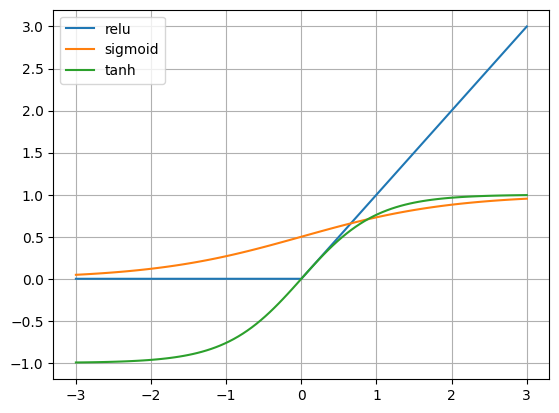

In [3]:
# The three classics plotted together. Note where each one flattens: that flat
# region has near-zero derivative, and a layer sitting in it stops learning.
activation_funcs = ['relu', 'sigmoid','tanh']


for i in activation_funcs:
  plt.plot(x,getFunc(i), label=f'{i}')
  plt.legend();

plt.grid();


In [4]:
# The same lookup against torch.nn, which holds activation CLASSES - so the
# extra () instantiates the layer before calling it.
def getFuncNN(funcName):

  func = getattr(torch.nn, funcName)()

  return func(x)

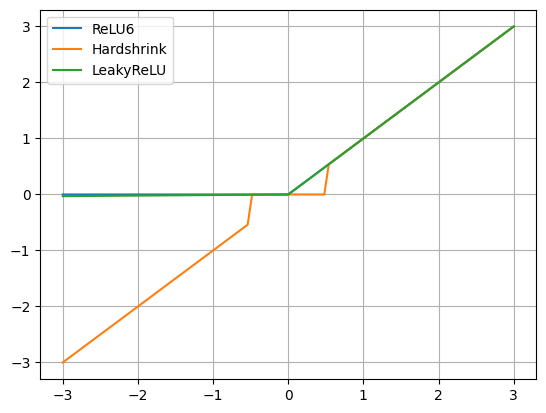

In [5]:
# Three variants: ReLU6 (clipped at 6, for quantised models), Hardshrink (zero
# in a band around 0) and LeakyReLU (small negative slope). More in the next
# notebook.
actFuns = ['ReLU6', 'Hardshrink', "LeakyReLU"]

for i in actFuns:
  plt.plot(x,getFuncNN(i), label=f'{i}')
  plt.legend();

plt.grid();


In [6]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

cols = X.columns

In [7]:
# Binarise wine quality, as in the previous notebook.
y['Bool Quality'] = y > 5
y['Bool Quality'] = y['Bool Quality'].astype(int)
y = y.drop('quality', axis=1)

/tmp/ipython-input-7-2717634329.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y > 5
/tmp/ipython-input-7-2717634329.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y['Bool Quality'] = y['Bool Quality'].astype(int)


In [8]:
x = torch.tensor(X.to_numpy(),dtype=torch.float,device='cuda')
y = torch.tensor(y.to_numpy(),dtype=torch.float,device='cuda')



In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(x,y , test_size=0.2)

train_data = TensorDataset(X_train,Y_train)
test_data = TensorDataset(X_test, Y_test)

bs = 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=bs, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0])

In [10]:
# The model takes the activation NAME in forward() and looks it up in
# torch.nn.functional. Unusual, but it lets one model object serve every run -
# which is also the source of the flaw noted below.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(11,128)

    self.fc1 = nn.Linear(128,128)

    self.output_layer = nn.Linear(128,1)

  def forward(self,x, funcName):

    funcName = getattr(F,funcName)

    x = funcName(self.input_layer(x))

    x = funcName(self.fc1(x))

    return self.output_layer(x)

In [11]:
# Shared hyperparameters for the sweep. The MODEL and OPTIMIZER are deliberately
# NOT created here - see train_model below, which builds a fresh one per run so
# the activations are compared from identical starting conditions.
epochs = 1000
lr = 0.001
lossFunc = nn.BCEWithLogitsLoss()

In [12]:
# Training function taking the activation name.
# The model and optimizer are built INSIDE, so every call starts from fresh
# random weights - without that the runs would continue each other's training
# and the comparison would be meaningless.
def train_model(actFunc):
  Classifier = model().to('cuda')
  optimizer = torch.optim.SGD(Classifier.parameters(), lr=lr)

  test_acc = []
  train_acc = []
  losses = torch.zeros(epochs)

  for epoch in range(epochs):

    Classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = Classifier.forward(x,actFunc)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # Test Train acc

      batch_acc.append( 100 * torch.mean( ((yhat > 0) == y).float()).item())

    train_acc.append(np.mean(batch_acc))
    losses[epoch] = np.mean(batch_loss)
    if epoch % 200 == 0 or epoch == epochs -1:
      print(f'{actFunc} : Epoch : {epoch} - Loss {losses[epoch]}')

    Classifier.eval()
    with torch.no_grad():
      X,Y =  next(iter(test_loader))
      preds = Classifier.forward(X,actFunc)
      test_acc.append(100 * torch.mean( ((preds>0) == Y).float()).item() )

  return test_acc, train_acc, losses

In [13]:
activation_funcs = ['relu', 'sigmoid','tanh']

In [14]:
# Three independent runs: relu, sigmoid, tanh, each from a fresh model.
final_test = []
final_train = []
final_losses = []

for actfun in activation_funcs:
  test_acc, train_acc, losses = train_model(actfun)

  final_test.append(test_acc)
  final_train.append(train_acc)
  final_losses.append(losses)
  print()

relu : Epoch : 0 - Loss 0.8654646873474121
relu : Epoch : 200 - Loss 0.5537024140357971
relu : Epoch : 400 - Loss 0.5372032523155212
relu : Epoch : 600 - Loss 0.5300297141075134
relu : Epoch : 800 - Loss 0.5235510468482971
relu : Epoch : 999 - Loss 0.5149345993995667

sigmoid : Epoch : 0 - Loss 0.664844274520874
sigmoid : Epoch : 200 - Loss 0.5933910608291626
sigmoid : Epoch : 400 - Loss 0.5635182857513428
sigmoid : Epoch : 600 - Loss 0.5485205054283142
sigmoid : Epoch : 800 - Loss 0.5384446382522583
sigmoid : Epoch : 999 - Loss 0.5307621359825134

tanh : Epoch : 0 - Loss 0.7639862298965454
tanh : Epoch : 200 - Loss 0.5255544185638428
tanh : Epoch : 400 - Loss 0.5168629288673401
tanh : Epoch : 600 - Loss 0.516889214515686
tanh : Epoch : 800 - Loss 0.5087608098983765
tanh : Epoch : 999 - Loss 0.5103181600570679



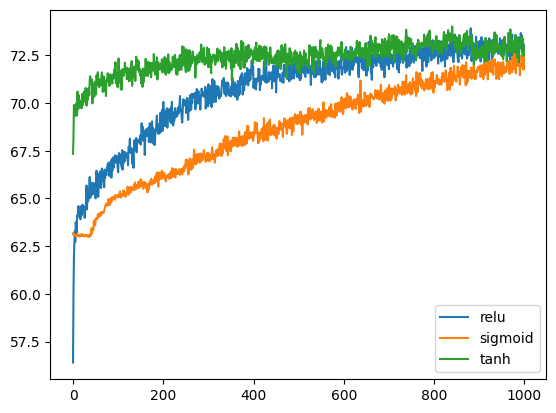

In [15]:
# Train accuracy per activation.
for i in range(3):
  plt.plot(final_train[i], label=activation_funcs[i])
  plt.legend();

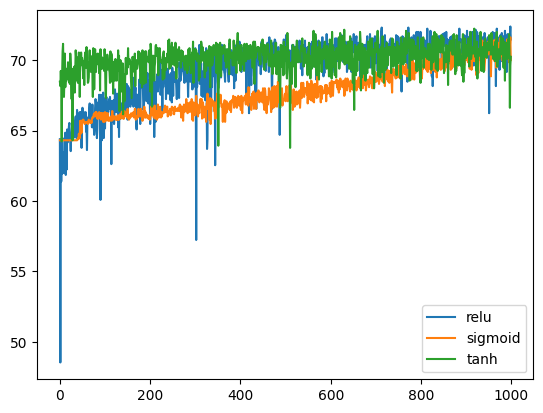

In [16]:
# Test accuracy per activation.
for i in range(3):
  plt.plot(final_test[i], label=activation_funcs[i])
  plt.legend();

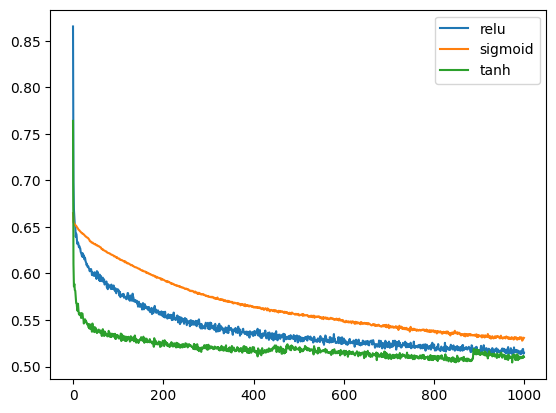

In [17]:
# Losses. Expect sigmoid to look worst and ReLU best on a network this size:
# sigmoid's derivative peaks at 0.25, so gradients shrink through every layer.
for i in range(3):
  plt.plot(final_losses[i], label=activation_funcs[i])
  plt.legend();